<a href="https://colab.research.google.com/github/ketanp23/deeplearningclass/blob/main/DL_Lab2_Learning_XOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DL Lab 2 · Learning XOR

> **Deep Learning foundations — Lab.** Run top to bottom (Runtime → Run all). Read the notes, run the code, and finish
> the **Your turn 🧪** cell. We build from scratch with NumPy so nothing is hidden.

## What you'll build
The problem that once stalled neural networks — **XOR** — and the fix: a **hidden layer** trained by back-propagation.
You'll see a single neuron fail, then a 2-layer network succeed, all in NumPy.

In [1]:
import numpy as np, matplotlib.pyplot as plt
VIOLET, CYAN = "#6C5CE7", "#22D3EE"
np.random.seed(1)
X = np.array([[0,0],[0,1],[1,0],[1,1]], float)
y = np.array([[0],[1],[1],[0]], float)     # XOR: 1 when inputs differ
print("XOR truth table:"); [print(x, "->", int(t)) for x,t in zip(X,y)]

XOR truth table:
[0. 0.] -> 0
[0. 1.] -> 1
[1. 0.] -> 1
[1. 1.] -> 0


/tmp/ipykernel_3208/1353561284.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("XOR truth table:"); [print(x, "->", int(t)) for x,t in zip(X,y)]


[None, None, None, None]

## 1 · Why a single neuron can't do it
Plot the four points. No straight line separates the two 1's from the two 0's — XOR is *not linearly separable*.

/tmp/ipykernel_3208/2710794287.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  zorder=3, label=f"class {int(ti)}")


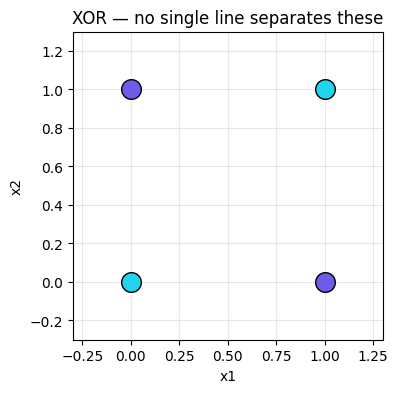

In [2]:
plt.figure(figsize=(4,4))
for xi, ti in zip(X, y):
    plt.scatter(*xi, c=(VIOLET if ti else CYAN), s=200, edgecolors='k',
                zorder=3, label=f"class {int(ti)}")
plt.title("XOR — no single line separates these"); plt.xlabel("x1"); plt.ylabel("x2")
plt.xlim(-.3,1.3); plt.ylim(-.3,1.3); plt.grid(alpha=.3); plt.show()

## 2 · A 2-layer network
One hidden layer of 4 tanh units, one sigmoid output. Forward pass, then back-prop the error to every weight.

In [3]:
def sigmoid(z): return 1/(1+np.exp(-z))

# weights
H = 4
W1 = np.random.randn(2, H);  b1 = np.zeros((1, H))
W2 = np.random.randn(H, 1);  b2 = np.zeros((1, 1))

lr, losses = 0.5, []
for epoch in range(5000):
    # ---- forward ----
    h  = np.tanh(X @ W1 + b1)          # hidden activations
    yh = sigmoid(h @ W2 + b2)          # output
    loss = np.mean((yh - y)**2)
    losses.append(loss)
    # ---- backward (chain rule) ----
    dyh = (yh - y) * yh * (1-yh)       # dL/d(output pre-activation)
    dW2 = h.T @ dyh;           db2 = dyh.sum(0, keepdims=True)
    dh  = (dyh @ W2.T) * (1-h**2)      # push through tanh'
    dW1 = X.T @ dh;            db1 = dh.sum(0, keepdims=True)
    # ---- update ----
    for p,g in [(W1,dW1),(b1,db1),(W2,dW2),(b2,db2)]:
        p -= lr * g / len(X)

print("final predictions:", np.round(yh.ravel(), 3))
print("final loss:", round(losses[-1], 5))

final predictions: [0.015 0.974 0.971 0.034]
final loss: 0.00072


## 3 · Watch it learn

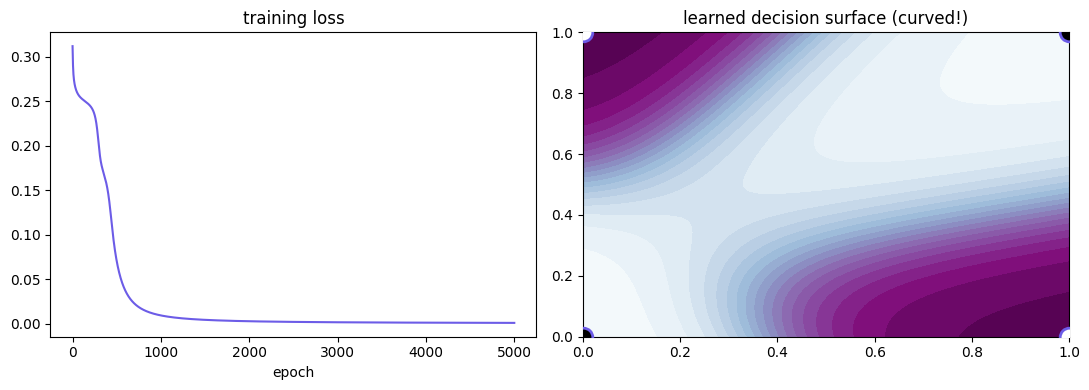

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(losses, color=VIOLET); ax[0].set_title("training loss"); ax[0].set_xlabel("epoch")
# decision surface
gx, gy = np.meshgrid(np.linspace(0,1,80), np.linspace(0,1,80))
grid = np.c_[gx.ravel(), gy.ravel()]
surf = sigmoid(np.tanh(grid @ W1 + b1) @ W2 + b2).reshape(gx.shape)
ax[1].contourf(gx, gy, surf, levels=20, cmap="BuPu")
for xi, ti in zip(X, y):
    ax[1].scatter(*xi, c=("white" if ti else "black"), s=180, edgecolors=VIOLET, linewidths=2, zorder=3)
ax[1].set_title("learned decision surface (curved!)")
plt.tight_layout(); plt.show()

## 4 · The single-neuron baseline (it fails)

In [5]:
w = np.random.randn(2,1); b = np.zeros((1,1))
for _ in range(5000):
    o = sigmoid(X @ w + b); d = (o-y)*o*(1-o)
    w -= 0.5*(X.T @ d)/4; b -= 0.5*d.sum(0,keepdims=True)/4
pred = (sigmoid(X @ w + b) > 0.5).astype(int).ravel()
print("single-neuron predictions:", pred, "  target:", y.ravel().astype(int))
print("accuracy:", (pred == y.ravel()).mean(), " <- can't reach 100% on XOR")

single-neuron predictions: [1 1 1 0]   target: [0 1 1 0]
accuracy: 0.75  <- can't reach 100% on XOR


## Your turn 🧪
1. Set `H = 1` hidden unit — does it still solve XOR? Find the smallest `H` that reliably works.
2. Replace `tanh` with `relu` in the hidden layer (remember to change its derivative to `(h>0)`). Does it train faster?
3. Lower the learning rate to `0.05` and raise epochs — compare the loss curve's shape.

In [6]:
# Your turn: try H=2 and see if it's enough
# (copy the training loop above, set H=2, and re-run)